# **Pavan S - 24BAD085**

---

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset

In [ ]:
path = kagglehub.dataset_download("uciml/autompg-dataset")
print("Dataset downloaded to:", path)

os.listdir(path)

100%|██████████| 6.31k/6.31k [00:00<00:00, 10.6MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/uciml/autompg-dataset/versions/3


['auto-mpg.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, "auto-mpg.csv"))
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [ ]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


## Data Cleaning

Data type before changing

In [ ]:
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model year,int64
origin,int64
car name,object


In [ ]:
df.replace("?", np.nan, inplace=True)
df["horsepower"] = pd.to_numeric(df["horsepower"])

df.dropna(inplace=True)

df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


Data type after changing

In [ ]:
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model year,int64
origin,int64
car name,object


## Feature Selection & Train-Test Split

In [ ]:
X = df[["horsepower"]]
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [1]:
def train_poly_model(degree):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Degree": degree,
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Model": model
    }

## Polynomial Regression Models

In [ ]:
results = []
models = {}

for d in [2, 3, 4]:
    out = train_poly_model(d)
    models[d] = out["Model"]
    results.append({k: v for k, v in out.items() if k != "Model"})

results_df = pd.DataFrame(results)
results_df

,Degree,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,2,19.204614,18.416968,4.382307,4.291499,0.695647,0.639170
1,3,19.143788,18.460267,4.375361,4.296541,0.696611,0.638322
2,4,19.126191,18.268227,4.373350,4.274135,0.696890,0.642084


## Polynomial Curve Fitting

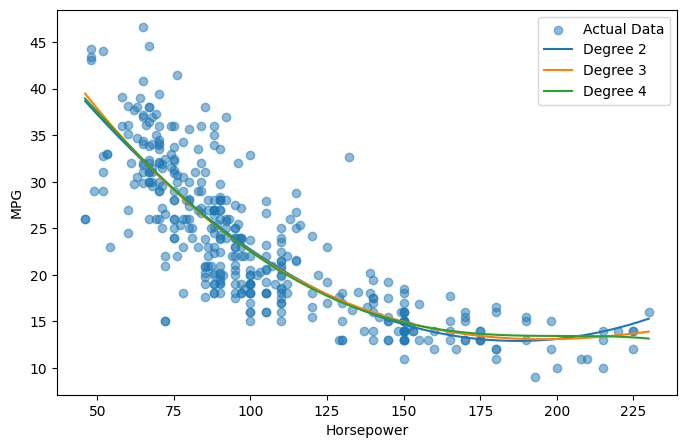

In [ ]:
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.5, label="Actual Data")

for d in [2, 3, 4]:
    plt.plot(X_range, models[d].predict(X_range), label=f"Degree {d}")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()
plt.show()

## Training vs Testing Error Comparison

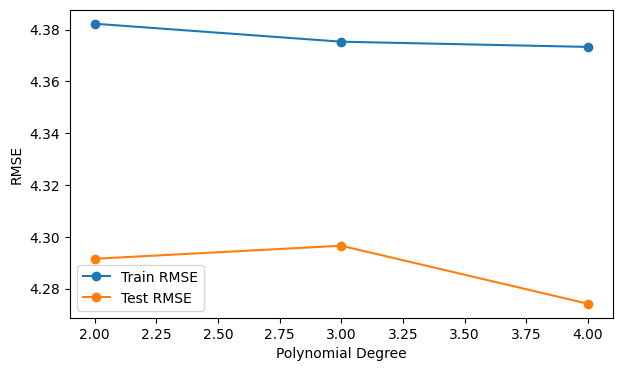

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(results_df["Degree"], results_df["Train RMSE"], marker="o", label="Train RMSE")
plt.plot(results_df["Degree"], results_df["Test RMSE"], marker="o", label="Test RMSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.legend()
plt.show()

## Ridge Regression

In [ ]:
def train_ridge(degree, alpha=1.0):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        "Degree": degree,
        "Alpha": alpha,
        "Ridge RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Ridge R2": r2_score(y_test, y_test_pred)
    }

ridge = []
for d in [2, 3, 4]:
    ridge.append(train_ridge(d))

pd.DataFrame(ridge)

,Degree,Alpha,Ridge RMSE,Ridge R2
0,2,1.0,4.252988,0.645617
1,3,1.0,4.272736,0.642318
2,4,1.0,4.278376,0.641374
